## Parameter Recovery Analysis Notebook

### Fixed Alpha

Relative Error=mean(
​θ^−θtrue​​/θtrue
​)

gamma_base relative error: 0.640
gamma_coef relative error: 1.697
beta relative error: 0.529
epsilon relative error: 2.105


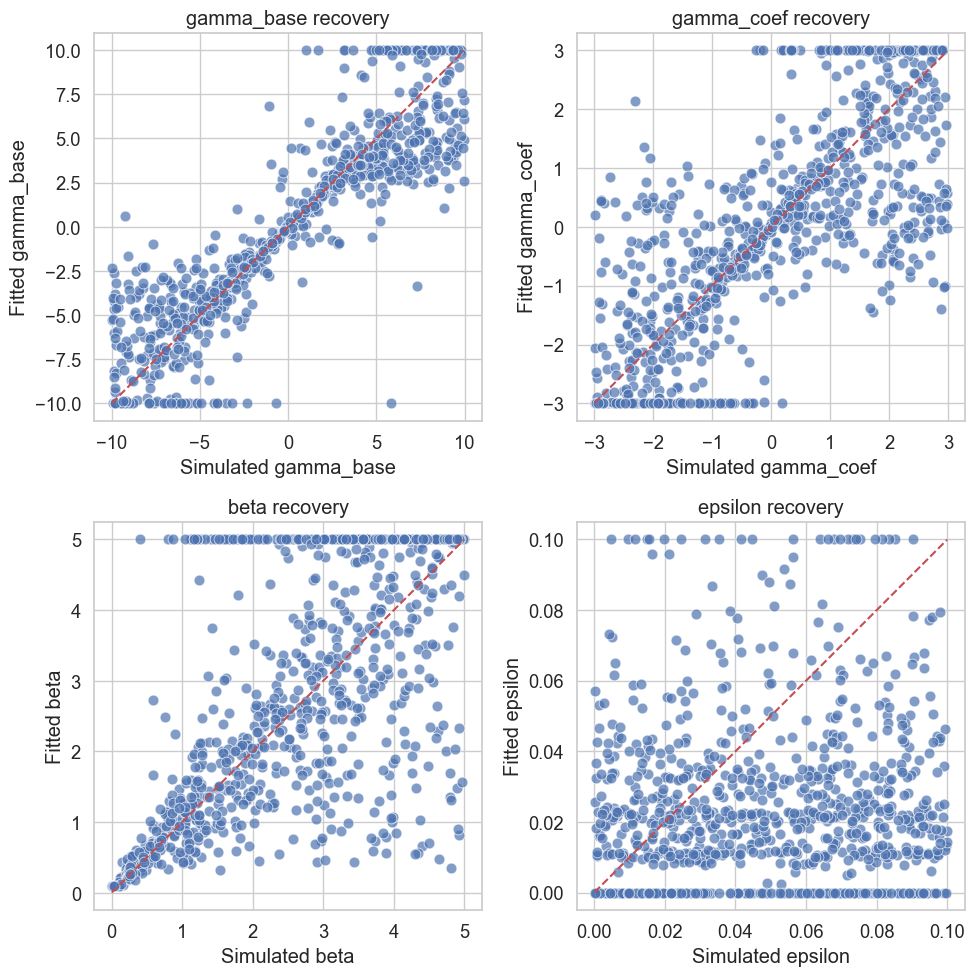

✅ Figure saved to: C:\Users\zyfxl\OneDrive - UC Irvine\UCI\CCNL Lab\Foraging Task Overview\parameter_recovery_plot.png


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# === Load files ===
fit_path = r"C:\Users\zyfxl\OneDrive - UC Irvine\UCI\CCNL Lab\Foraging Task Overview\foraging_MQLP-main\foraging_MQLP-main\model\model_parameter_recovery_clean_version\fit fixed alpha model to sim data and generate recovery stats\fit_all_alpha1_summary_epsilon.csv"
sim_path = r"C:\Users\zyfxl\OneDrive - UC Irvine\UCI\CCNL Lab\Foraging Task Overview\foraging_MQLP-main\foraging_MQLP-main\model\model_parameter_recovery_clean_version\generate sim data given alpha star\simulated_structure_learning_RANDOM_1000.csv"

fit_df = pd.read_csv(fit_path)
sim_df = pd.read_csv(sim_path)

# === Clean and align ===
# Remove duplicate rows from sim file (since parameters repeat per trial)
sim_df_unique = sim_df.drop_duplicates(subset=['sub_num'])[
    ['sub_num', 'gamma_base', 'gamma_coef', 'beta', 'epsilon']
]
fit_df = fit_df[['sub_num', 'gamma_base', 'gamma_coef', 'beta', 'epsilon']]

# Merge on subject number
merged = pd.merge(sim_df_unique, fit_df, on='sub_num', suffixes=('_sim', '_fit'))

# === Compute relative error ===
params = ['gamma_base', 'gamma_coef', 'beta', 'epsilon']
for p in params:
    rel_error = np.mean(np.abs((merged[f'{p}_fit'] - merged[f'{p}_sim']) / merged[f'{p}_sim']))
    print(f"{p} relative error: {rel_error:.3f}")

# === Plot parameter recovery ===
sns.set(style='whitegrid', font_scale=1.2)
fig, axes = plt.subplots(2, 2, figsize=(10, 10))

for ax, p in zip(axes.flatten(), params):
    sns.scatterplot(x=f'{p}_sim', y=f'{p}_fit', data=merged, ax=ax, s=60, alpha=0.7)
    ax.plot([merged[f'{p}_sim'].min(), merged[f'{p}_sim'].max()],
            [merged[f'{p}_sim'].min(), merged[f'{p}_sim'].max()],
            'r--', linewidth=1.5)
    ax.set_title(f'{p} recovery')
    ax.set_xlabel(f'Simulated {p}')
    ax.set_ylabel(f'Fitted {p}')

plt.tight_layout()

# === Save figure ===
save_path = r"C:\Users\zyfxl\OneDrive - UC Irvine\UCI\CCNL Lab\Foraging Task Overview\parameter_recovery_plot.png"
plt.savefig(save_path, dpi=300, bbox_inches='tight')

plt.show()
print(f"✅ Figure saved to: {save_path}")

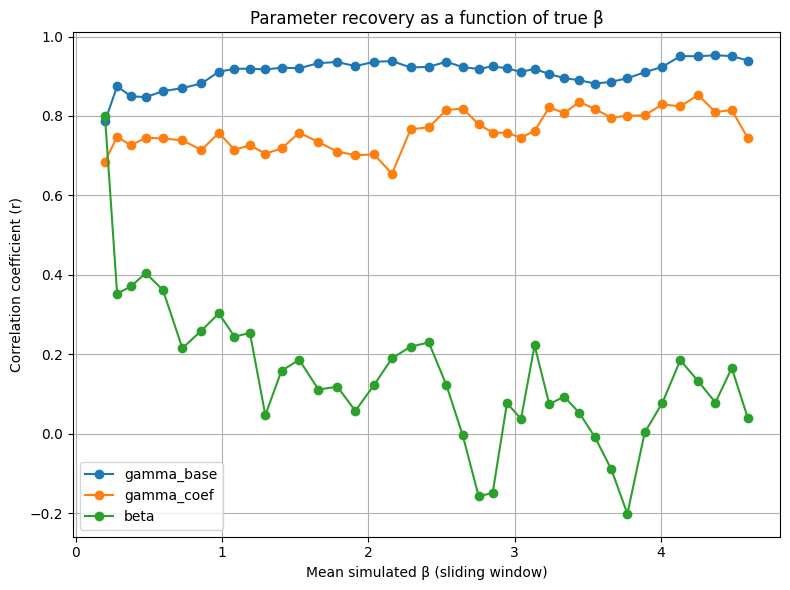

✅ Correlation-vs-beta figure saved to: C:\Users\zyfxl\OneDrive - UC Irvine\UCI\CCNL Lab\Foraging Task Overview\parameter_recovery_corr_vs_beta.png


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import pearsonr

# === Load files ===
fit_path = r"C:\Users\zyfxl\OneDrive - UC Irvine\UCI\CCNL Lab\Foraging Task Overview\foraging_MQLP-main\foraging_MQLP-main\model\model_parameter_recovery_clean_version\fit model to sim data and generate recovery stats\fit_all_alpha1_summary.csv"
sim_path = r"C:\Users\zyfxl\OneDrive - UC Irvine\UCI\CCNL Lab\Foraging Task Overview\foraging_MQLP-main\foraging_MQLP-main\model\model_parameter_recovery_clean_version\generate sim data given alpha star\simulated_structure_learning_RANDOM_1000.csv"

fit_df = pd.read_csv(fit_path)
sim_df = pd.read_csv(sim_path)

# === Clean and align ===
sim_df_unique = sim_df.drop_duplicates(subset=['sub_num'])[
    ['sub_num', 'gamma_base', 'gamma_coef', 'beta', 'epsilon']
]
fit_df = fit_df[['sub_num', 'gamma_base', 'gamma_coef', 'beta', 'epsilon']]

merged = pd.merge(sim_df_unique, fit_df, on='sub_num', suffixes=('_sim', '_fit'))

# === Sliding window correlation analysis ===
window_size = 100
step_size = 20

merged_sorted = merged.sort_values(by='beta_sim').reset_index(drop=True)

window_means = []
corr_results = {p: [] for p in ['gamma_base', 'gamma_coef', 'beta']}

for start in range(0, len(merged_sorted) - window_size + 1, step_size):
    window = merged_sorted.iloc[start:start + window_size]
    mean_beta = window['beta_sim'].mean()
    window_means.append(mean_beta)
    
    for p in corr_results.keys():
        r, _ = spearmanr(window[f'{p}_sim'], window[f'{p}_fit'])
        corr_results[p].append(r)

# === Plot correlation vs mean beta ===
plt.figure(figsize=(8,6))
for p in corr_results.keys():
    plt.plot(window_means, corr_results[p], marker='o', label=p)

plt.xlabel('Mean simulated β (sliding window)')
plt.ylabel('Correlation coefficient (r)')
plt.title('Parameter recovery as a function of true β')
plt.legend()
plt.grid(True)
plt.tight_layout()

# Save figure
save_path_corr = r"C:\Users\zyfxl\OneDrive - UC Irvine\UCI\CCNL Lab\Foraging Task Overview\parameter_recovery_corr_vs_beta.png"
plt.savefig(save_path_corr, dpi=300, bbox_inches='tight')
plt.show()
print(f"✅ Correlation-vs-beta figure saved to: {save_path_corr}")


### Free Alpha

Loaded: C:/Users/zyfxl/OneDrive - UC Irvine/UCI/CCNL Lab/Foraging Task Overview/foraging_MQLP-main/foraging_MQLP-main/model/model_parameter_recovery_clean_version/generate sim data with free alpha range/parameter_recovery_results.csv
N rows: 204


,sub_num,alpha_est,gamma_base_est,gamma_coef_est,alpha_true,gamma_base_true,gamma_coef_true
0,1,6.083984,-1.464844,1.669922,7.444696,-1.966658,2.006188
1,2,5.237793,3.891602,-1.583496,5.446801,9.967795,-2.240115
2,3,3.444824,8.149414,-2.907715,7.950531,-1.360985,-1.518685
3,4,7.731934,-2.260742,0.531738,1.127765,-6.465376,1.677248
4,5,8.220215,0.825195,-0.159668,3.603259,-4.491744,-1.271876


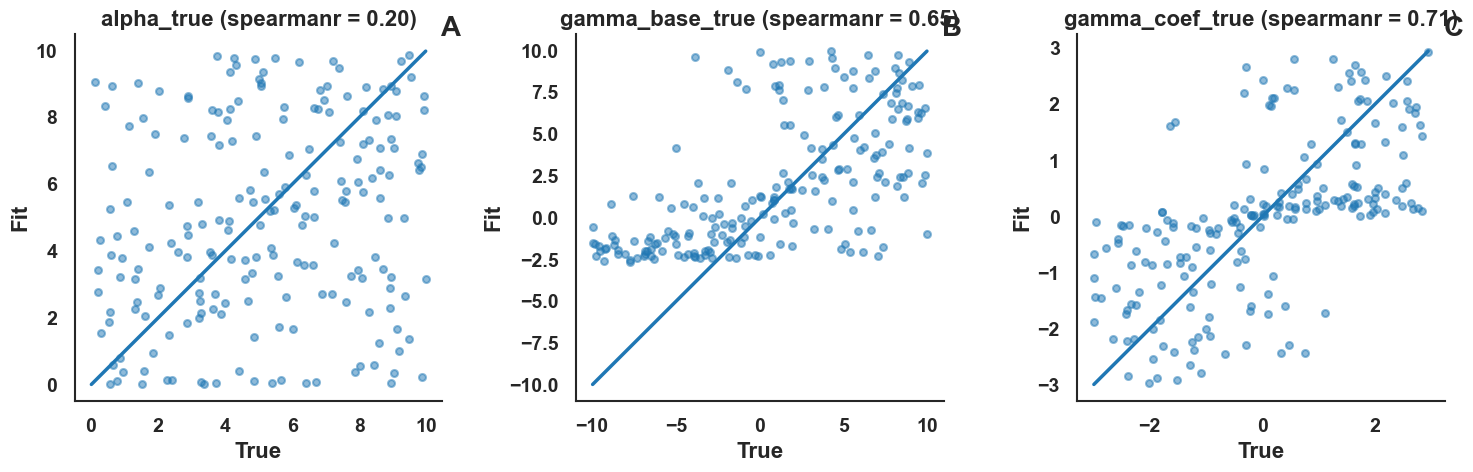

In [ ]:
# ============================================================
# Free Alpha: Parameter Recovery (Publication Quality)
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from scipy.stats import spearmanr

# ---------------------------
# 1) Load data
# ---------------------------
recovery_csv = "C:/Users/zyfxl/OneDrive - UC Irvine/UCI/CCNL Lab/Foraging Task Overview/foraging_MQLP-main/foraging_MQLP-main/model/model_parameter_recovery_clean_version/generate sim data with free alpha range/parameter_recovery_results_5.21.csv"

df = pd.read_csv(recovery_csv)

print("Loaded:", recovery_csv)
display(df.head())

# ---------------------------
# 2) Parameters
# ---------------------------
param_pairs = [
    ("alpha_true", "alpha_est"),
    ("gamma_base_true", "gamma_base_est"),
    ("gamma_coef_true", "gamma_coef_est"),
]

labels = ["A", "B", "C"]

# ---------------------------
# 3) Plot settings (publication style)
# ---------------------------
plt.rcParams.update({
    "font.size": 16,
    "font.weight": "bold",
    "axes.labelweight": "bold",
    "axes.titleweight": "bold",
})

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, (ax, (true_col, fit_col)) in enumerate(zip(axes, param_pairs)):
    sub = df[[true_col, fit_col]].dropna()
    x = sub[true_col].values
    y = sub[fit_col].values

    # correlation
    r, p = spearmanr(x, y)

    # scatter
    ax.scatter(x, y, s=25, alpha=0.5)

    # identity line
    lo = min(x.min(), y.min())
    hi = max(x.max(), y.max())
    ax.plot([lo, hi], [lo, hi], lw=2.5)

    # title (NO p-value)
    ax.set_title(f"{true_col} (spearmanr = {r:.2f})", fontsize=16, fontweight='bold')

    # OPTIONAL: include p-value if needed
    # ax.set_title(f"{true_col} (r = {r:.2f}, p = {p:.1e})", fontsize=16, fontweight='bold')

    # labels
    ax.set_xlabel("True", fontsize=16)
    ax.set_ylabel("Fit", fontsize=16)

    # remove grid
    ax.grid(False)

    # clean spines
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # thicker axis lines
    ax.spines["left"].set_linewidth(1.5)
    ax.spines["bottom"].set_linewidth(1.5)

    # ticks
    ax.tick_params(axis='both', labelsize=14, width=1.5)

    # subplot label (A, B, C) — top right
    ax.text(
        1.05, 1.05, labels[i],
        transform=ax.transAxes,
        fontsize=20,
        fontweight='bold',
        ha='right',
        va='top'
    )



plt.tight_layout()
plt.show()

Loaded: C:/Users/zyfxl/OneDrive - UC Irvine/UCI/CCNL Lab/Foraging Task Overview/foraging_MQLP-main/foraging_MQLP-main/model/model_parameter_recovery_clean_version/generate sim data with free alpha range/parameter_recovery_results_5.21.csv
N rows: 204


,sub_num,alpha_est,gamma_base_est,gamma_coef_est,alpha_true,gamma_base_true,gamma_coef_true
0,1,6.083984,-1.464844,1.669922,7.444696,-1.966658,2.006188
1,2,5.237793,3.891602,-1.583496,5.446801,9.967795,-2.240115
2,3,3.444824,8.149414,-2.907715,7.950531,-1.360985,-1.518685
3,4,7.731934,-2.260742,0.531738,1.127765,-6.465376,1.677248
4,5,4.220215,0.825195,-0.159668,3.603259,-4.491744,-1.271876


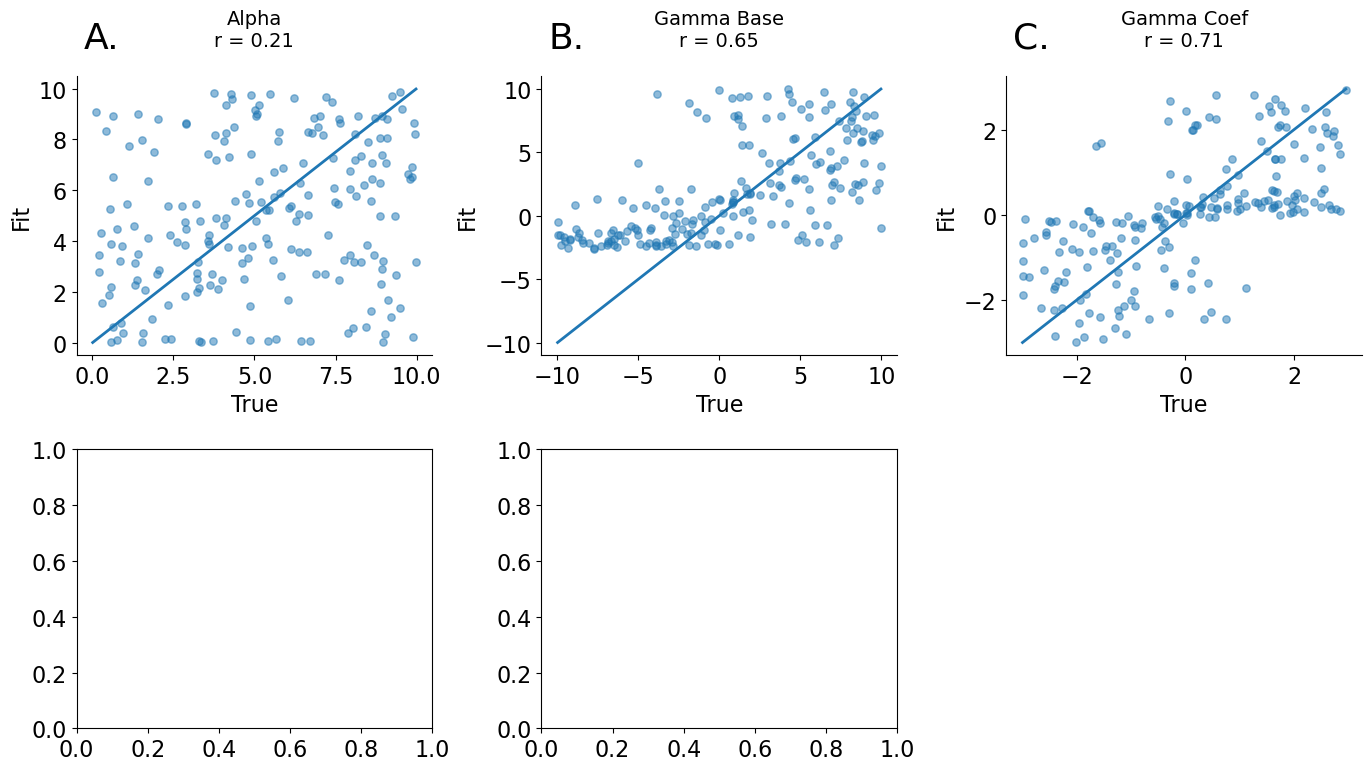

Loaded alpha->modeK lookup from: C:/Users/zyfxl/OneDrive - UC Irvine/UCI/CCNL Lab/Foraging Task Overview/foraging_MQLP-main/foraging_MQLP-main/model/simulations/results_alpha_bins/alpha_planet_bins.txt


,alpha,modeK,meanK,varK
0,0.0,1,1.00,0.000
1,0.1,2,2.48,0.979
2,0.2,3,2.80,1.071
3,0.3,3,3.08,0.862
4,0.4,3,3.30,0.818


Planet-bin recovery accuracy (nearest-grid bins): 0.686


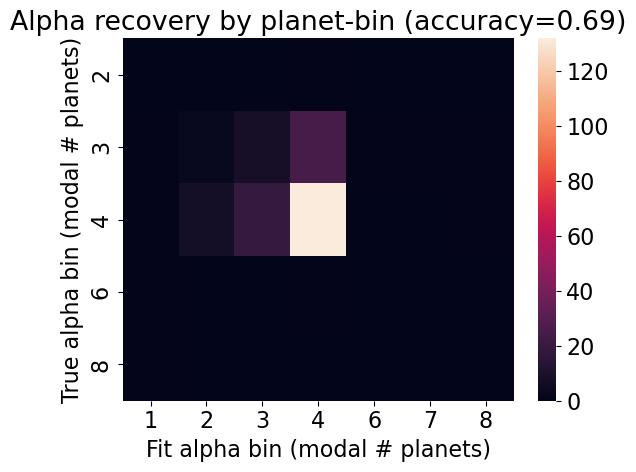

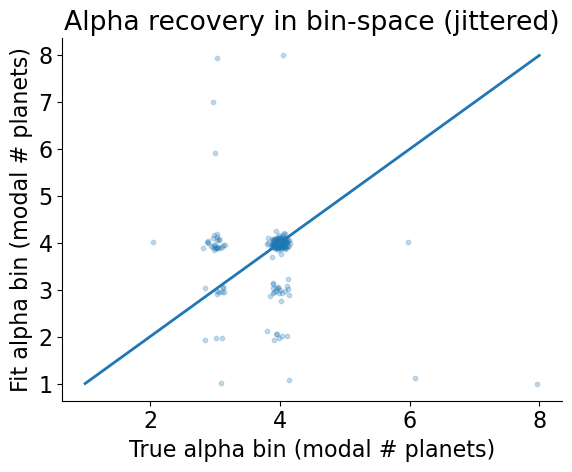

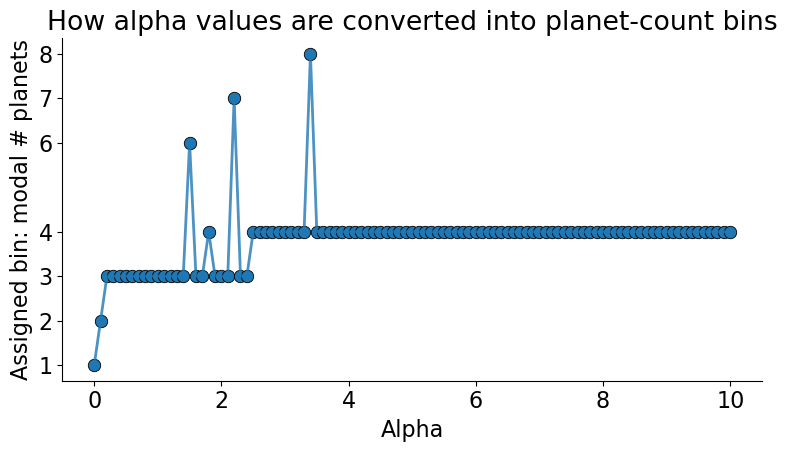

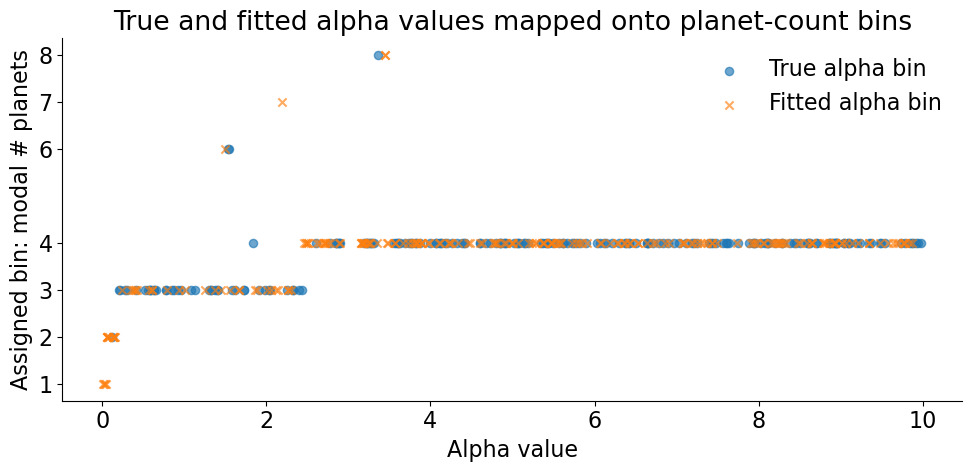


Alpha-bin lookup table:


,alpha,modeK,meanK,varK,alpha_lower_bound,alpha_upper_bound
0,0.0,1,1.00,0.000,-inf,0.05
1,0.1,2,2.48,0.979,0.05,0.15
2,0.2,3,2.80,1.071,0.15,0.25
3,0.3,3,3.08,0.862,0.25,0.35
4,0.4,3,3.30,0.818,0.35,0.45
...,...,...,...,...,...,...
96,9.6,4,9.35,27.563,9.55,9.65
97,9.7,4,8.20,23.798,9.65,9.75
98,9.8,4,9.82,24.937,9.75,9.85
99,9.9,4,9.40,24.626,9.85,9.95


Saved alpha bin table to alpha_bin_intervals_modeK.csv


In [2]:
# ============================================================
# Free Alpha: Parameter Recovery + Alpha Bin Recovery
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
from scipy.stats import spearmanr

# ---------------------------
# 1) Load free-alpha recovery results
# ---------------------------
# TODO: update this path to your local folder if needed
recovery_csv = "C:/Users/zyfxl/OneDrive - UC Irvine/UCI/CCNL Lab/Foraging Task Overview/foraging_MQLP-main/foraging_MQLP-main/model/model_parameter_recovery_clean_version/generate sim data with free alpha range/parameter_recovery_results_5.21.csv"
df = pd.read_csv(recovery_csv)

print("Loaded:", recovery_csv)
print("N rows:", len(df))
display(df.head())

# ---------------------------
# 2) Standard recovery plots for all parameters (true vs fit)
# ---------------------------
param_pairs = [
    ("alpha_true", "alpha_est"),
    ("gamma_base_true", "gamma_base_est"),
    ("gamma_coef_true", "gamma_coef_est"),
]


plt.rcParams.update({
    "font.size": 16,
    "font.weight": "normal",
    "axes.labelweight": "normal",
    "axes.titleweight": "normal",
})


fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

letters = ["A.", "B.", "C."]

# ✅ Pretty names for each parameter
param_name_map = {
    "alpha_true": "Alpha",
    "gamma_base_true": "Gamma Base",
    "gamma_coef_true": "Gamma Coef",
}

for i, (ax, (true_col, fit_col)) in enumerate(zip(axes, param_pairs)):
    sub = df[[true_col, fit_col]].dropna()
    x = sub[true_col].values
    y = sub[fit_col].values

    # correlation
    r, p = spearmanr(x, y)

    ax.scatter(x, y, s=28, alpha=0.5)
    lo = min(x.min(), y.min())
    hi = max(x.max(), y.max())
    ax.plot([lo, hi], [lo, hi], lw=2)

    # ✅ Use clean parameter name
    pretty_name = param_name_map[true_col]

    ax.set_title(
        f"{pretty_name}\n"
        f"r = {r:.2f}\n",
       # f"p = {p:.1e}",
        fontsize=14
    )

    ax.set_xlabel("True")
    ax.set_ylabel("Fit")

    # subplot label
    ax.text(
        0.02, 1.2, letters[i],
        transform=ax.transAxes,
        fontsize=26,
        fontweight="normal",
        va="top",
        ha="left"
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

# hide unused panel
axes[-1].axis("off")
plt.tight_layout()
plt.show()

# ============================================================
# 3) Alpha-specific recovery using "planet-bin" assignment
#    (bin alpha by MODAL recovered planet count)
# ============================================================

# You need the alpha->modeK lookup created from the big CRP sweep.
# This is the text file produced by make_alpha_planet_bins.jl:
#   results_alpha_bins/alpha_planet_bins.txt
#
# If you used a different folder name, update ALPHA_BIN_TXT.

ALPHA_BIN_TXT = r"C:/Users/zyfxl/OneDrive - UC Irvine/UCI/CCNL Lab/Foraging Task Overview/foraging_MQLP-main/foraging_MQLP-main/model/simulations/results_alpha_bins/alpha_planet_bins.txt"

# --- Parse the table section (alpha, modeK, meanK, varK) ---
# The file contains header lines and a separator; we extract the block between
# the dashed line and the next blank line.
with open(ALPHA_BIN_TXT, "r", encoding="utf-8") as f:
    lines = f.readlines()

# find table start after a line of dashes
start = None
for i, line in enumerate(lines):
    if set(line.strip()) == {"-"}:
        start = i + 1
        break
if start is None:
    raise ValueError("Could not find table separator line in alpha_planet_bins.txt")

# read table rows until an empty line or 'Bins (' line
rows = []
for line in lines[start:]:
    if not line.strip():
        break
    if line.strip().startswith("Bins"):
        break
    parts = line.split()
    # expected: alpha modeK meanK varK
    if len(parts) >= 4:
        rows.append(parts[:4])

alpha_map = pd.DataFrame(rows, columns=["alpha", "modeK", "meanK", "varK"]).astype(float)
alpha_map["modeK"] = alpha_map["modeK"].astype(int)

print("Loaded alpha->modeK lookup from:", ALPHA_BIN_TXT)
display(alpha_map.head())

# --- Build fast nearest-neighbor lookup on the alpha grid ---
grid_alpha = alpha_map["alpha"].values
grid_modeK = alpha_map["modeK"].values

def alpha_to_bin(alpha_values: np.ndarray) -> np.ndarray:
    """Assign each alpha to the nearest grid alpha's modal planet-count bin."""
    alpha_values = np.asarray(alpha_values, dtype=float)
    idx = np.abs(alpha_values[:, None] - grid_alpha[None, :]).argmin(axis=1)
    return grid_modeK[idx]

df["alpha_bin_true"] = alpha_to_bin(df["alpha_true"].values)
df["alpha_bin_fit"]  = alpha_to_bin(df["alpha_est"].values)

# --- Summary stats ---
bin_acc = (df["alpha_bin_true"] == df["alpha_bin_fit"]).mean()
print(f"Planet-bin recovery accuracy (nearest-grid bins): {bin_acc:.3f}")

# --- Confusion matrix heatmap ---
cm = pd.crosstab(df["alpha_bin_true"], df["alpha_bin_fit"])
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=False, fmt="d", cbar=True)
plt.xlabel("Fit alpha bin (modal # planets)")
plt.ylabel("True alpha bin (modal # planets)")
plt.title(f"Alpha recovery by planet-bin (accuracy={bin_acc:.2f})")
plt.tight_layout()
plt.show()

# --- Scatter (bin vs bin) with jitter for readability ---
rng = np.random.default_rng(0)
x = df["alpha_bin_true"].values + rng.normal(0, 0.08, size=len(df))
y = df["alpha_bin_fit"].values  + rng.normal(0, 0.08, size=len(df))

plt.figure(figsize=(6, 5))
plt.scatter(x, y, s=10, alpha=0.25)
lo = min(df["alpha_bin_true"].min(), df["alpha_bin_fit"].min())
hi = max(df["alpha_bin_true"].max(), df["alpha_bin_fit"].max())
plt.plot([lo, hi], [lo, hi], lw=2)
plt.xlabel("True alpha bin (modal # planets)")
plt.ylabel("Fit alpha bin (modal # planets)")
plt.title("Alpha recovery in bin-space (jittered)")
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.tight_layout()
plt.show()


# ============================================================
# Extra visualization: alpha value -> planet-bin belonging
# ============================================================

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Make sure bin error exists
df["bin_error"] = (df["alpha_bin_fit"] - df["alpha_bin_true"]).abs()

# ------------------------------------------------------------
# 1) Visualize the alpha-to-bin mapping itself
# ------------------------------------------------------------

plt.figure(figsize=(8, 4.8))

plt.scatter(
    alpha_map["alpha"],
    alpha_map["modeK"],
    s=80,
    edgecolor="black",
    linewidth=0.6
)

plt.plot(
    alpha_map["alpha"],
    alpha_map["modeK"],
    linewidth=2,
    alpha=0.8
)

plt.xlabel("Alpha")
plt.ylabel("Assigned bin: modal # planets")
plt.title("How alpha values are converted into planet-count bins")

plt.yticks(sorted(alpha_map["modeK"].unique()))

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 2) Show true alpha and fitted alpha belonging on the same axis
# ------------------------------------------------------------

plot_df = df.copy()

# Optional: sort by true alpha for easier visualization
plot_df = plot_df.sort_values("alpha_true").reset_index(drop=True)

plt.figure(figsize=(10, 5))

plt.scatter(
    plot_df["alpha_true"],
    plot_df["alpha_bin_true"],
    s=35,
    alpha=0.65,
    label="True alpha bin"
)

plt.scatter(
    plot_df["alpha_est"],
    plot_df["alpha_bin_fit"],
    s=35,
    alpha=0.65,
    marker="x",
    label="Fitted alpha bin"
)

plt.xlabel("Alpha value")
plt.ylabel("Assigned bin: modal # planets")
plt.title("True and fitted alpha values mapped onto planet-count bins")

plt.yticks(sorted(alpha_map["modeK"].unique()))
plt.legend(frameon=False)

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()





# ============================================================
# Show the bins themselves: alpha intervals -> modeK bin

alpha_bins = alpha_map[["alpha", "modeK", "meanK", "varK"]].copy()
alpha_bins = alpha_bins.sort_values("alpha").reset_index(drop=True)

grid_alpha = alpha_bins["alpha"].values

# Compute nearest-neighbor interval boundaries
lower_bounds = []
upper_bounds = []

for i, a in enumerate(grid_alpha):
    if i == 0:
        lower = -np.inf
    else:
        lower = (grid_alpha[i - 1] + grid_alpha[i]) / 2

    if i == len(grid_alpha) - 1:
        upper = np.inf
    else:
        upper = (grid_alpha[i] + grid_alpha[i + 1]) / 2

    lower_bounds.append(lower)
    upper_bounds.append(upper)

alpha_bins["alpha_lower_bound"] = lower_bounds
alpha_bins["alpha_upper_bound"] = upper_bounds

print("\nAlpha-bin lookup table:")
display(alpha_bins)

# Optional: save this table
alpha_bins.to_csv("alpha_bin_intervals_modeK.csv", index=False)
print("Saved alpha bin table to alpha_bin_intervals_modeK.csv")

   sub_num  alpha_est  gamma_base_est  gamma_coef_est  alpha_true  \
0        1   6.083984       -1.464844        1.669922    7.444696   
1        2   5.237793        3.891602       -1.583496    5.446801   
2        3   3.444824        8.149414       -2.907715    7.950531   
3        4   7.731934       -2.260742        0.531738    1.127765   
4        5   8.220215        0.825195       -0.159668    3.603259   

   gamma_base_true  gamma_coef_true  
0        -1.966658         2.006188  
1         9.967795        -2.240115  
2        -1.360985        -1.518685  
3        -6.465376         1.677248  
4        -4.491744        -1.271876  
Index(['sub_num', 'alpha_est', 'gamma_base_est', 'gamma_coef_est',
       'alpha_true', 'gamma_base_true', 'gamma_coef_true'],
      dtype='object')
Plotting columns:
['alpha_est', 'gamma_base_est', 'gamma_coef_est', 'alpha_true', 'gamma_base_true', 'gamma_coef_true']


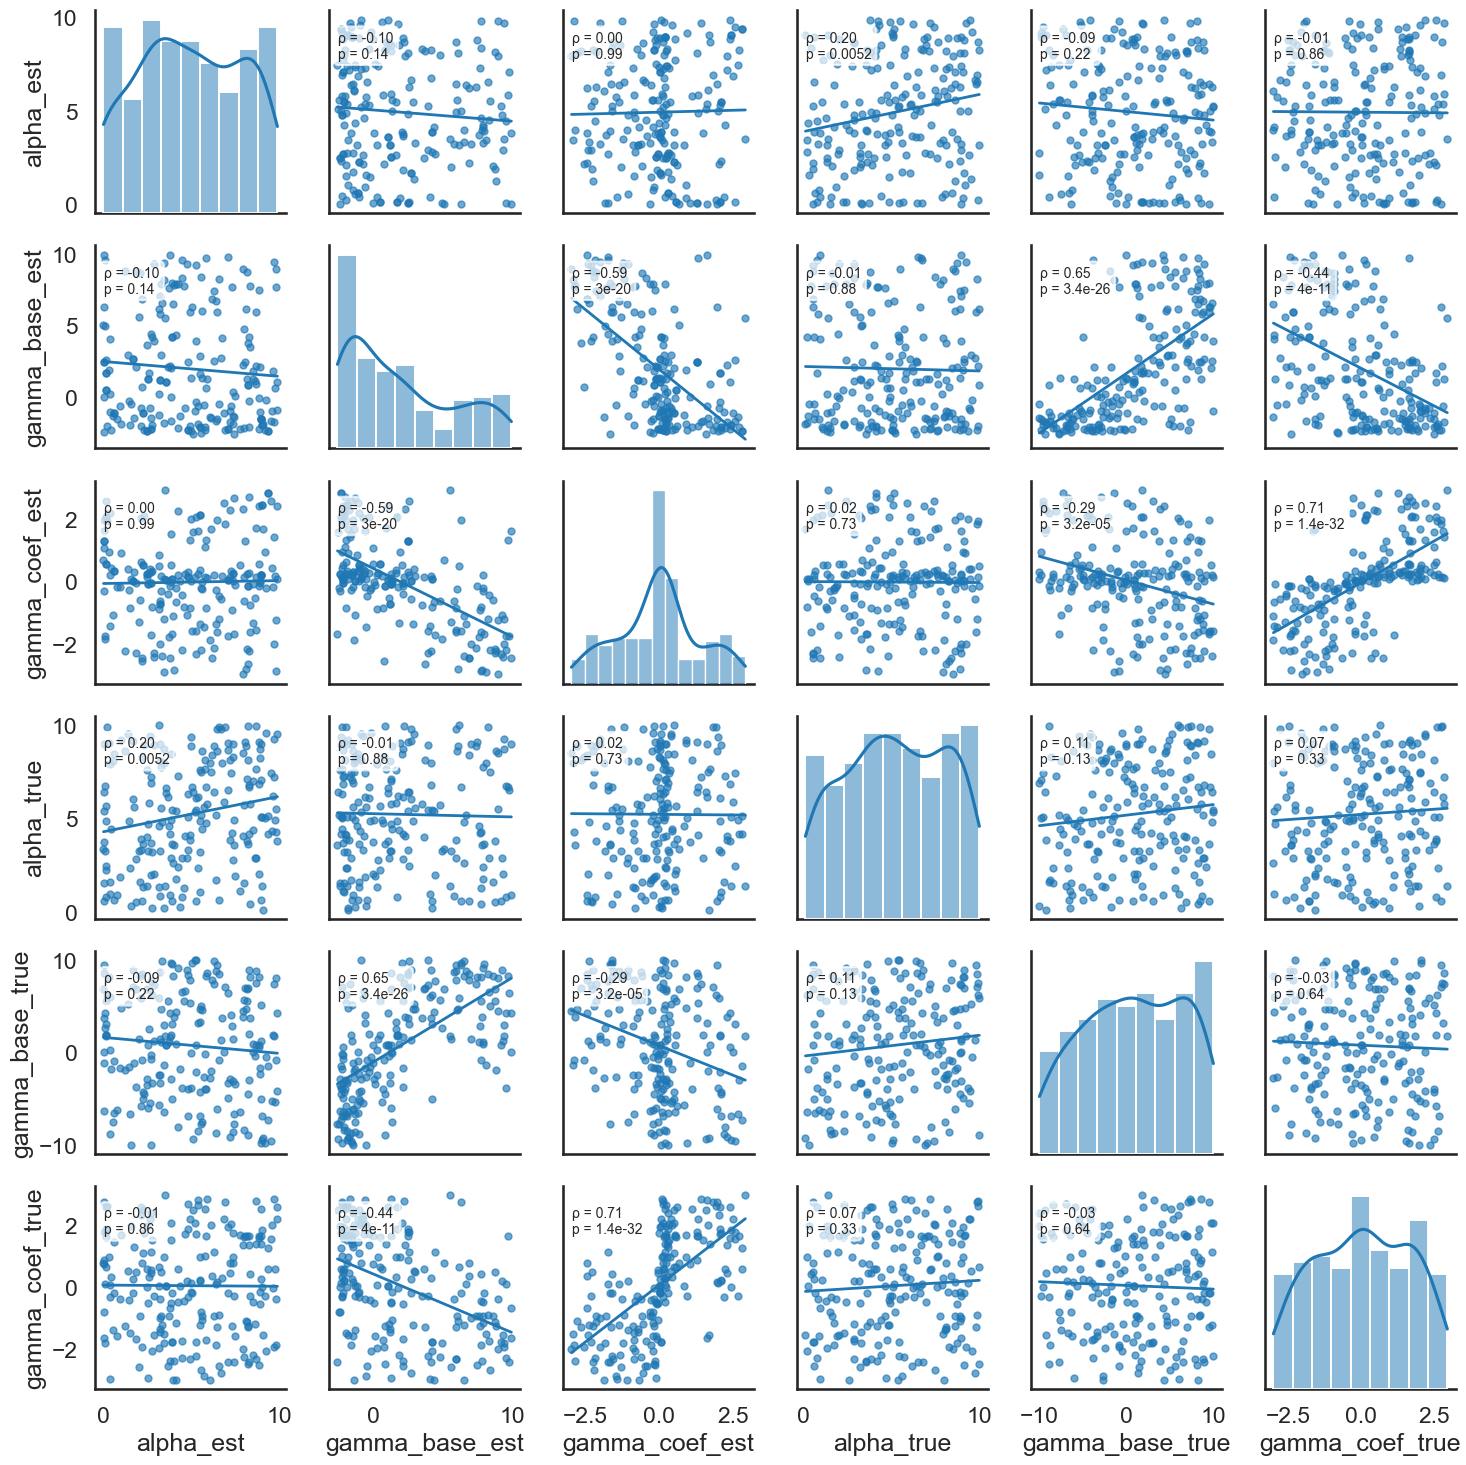

In [9]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

# -----------------------------
# Load data
# -----------------------------
csv_path = r"C:\Users\zyfxl\OneDrive - UC Irvine\UCI\CCNL Lab\Foraging Task Overview\foraging_MQLP-main\foraging_MQLP-main\model\model_parameter_recovery_clean_version\generate sim data with free alpha range\parameter_recovery_results.csv"

df = pd.read_csv(csv_path)
print(df.head())
print(df.columns)

# -----------------------------
# Select numeric columns
# Modify this list if needed
# -----------------------------
numeric_cols = df.select_dtypes(include="number").columns.tolist()

# Optional: remove ID-like columns
exclude_cols = ["subject", "subject_num", "sub_num", "id"]
plot_cols = [c for c in numeric_cols if c.lower() not in exclude_cols]

print("Plotting columns:")
print(plot_cols)

# -----------------------------
# Spearman annotation function
# -----------------------------
def annotate_spearman(x, y, **kwargs):
    ax = plt.gca()

    valid = pd.DataFrame({"x": x, "y": y}).dropna()
    if len(valid) < 3:
        return

    rho, p = spearmanr(valid["x"], valid["y"])

    ax.text(
        0.05, 0.90,
        f"ρ = {rho:.2f}\np = {p:.2g}",
        transform=ax.transAxes,
        fontsize=10,
        verticalalignment="top",
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.7)
    )

# -----------------------------
# Pairwise scatter plot
# -----------------------------
sns.set_context("talk")
sns.set_style("white")

g = sns.PairGrid(df[plot_cols], diag_sharey=False)

g.map_upper(
    sns.regplot,
    scatter_kws={"s": 25, "alpha": 0.65},
    line_kws={"linewidth": 2},
    ci=None
)

g.map_lower(
    sns.regplot,
    scatter_kws={"s": 25, "alpha": 0.65},
    line_kws={"linewidth": 2},
    ci=None
)

g.map_lower(annotate_spearman)
g.map_upper(annotate_spearman)

g.map_diag(sns.histplot, kde=True)

for ax in g.axes.flatten():
    if ax is not None:
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

plt.tight_layout()



## Alpha bin-wise recovery

DISCRETE ALPHA RECOVERY
N = 204
ModeK hit rate = 0.686
MedianK-rounded hit rate = 0.167

ModeK confusion matrix:
alpha_modeK_fit   1  2   3    4  6  7  8
alpha_modeK_true                        
1                 0  0   0    0  0  0  0
2                 0  0   0    1  0  0  0
3                 1  3   8   25  1  1  1
4                 1  7  19  132  0  0  1
6                 1  0   0    1  0  0  0
7                 0  0   0    0  0  0  0
8                 1  0   0    0  0  0  0

MeanK-rounded confusion matrix:
alpha_meanK_bin_fit   1   2   3   4   5   6   7   8   9   10
alpha_meanK_bin_true                                        
1                      0   0   0   0   0   0   0   0   0   0
2                      0   0   0   0   0   0   0   0   0   1
3                      0   0   0   0   2   1   2   0   1   0
4                      1   1   1   2   0   4   5   2   1   1
5                      1   0   1   1   1   5   0   2   3   0
6                      0   3   0   0   4   4  11   3   5  

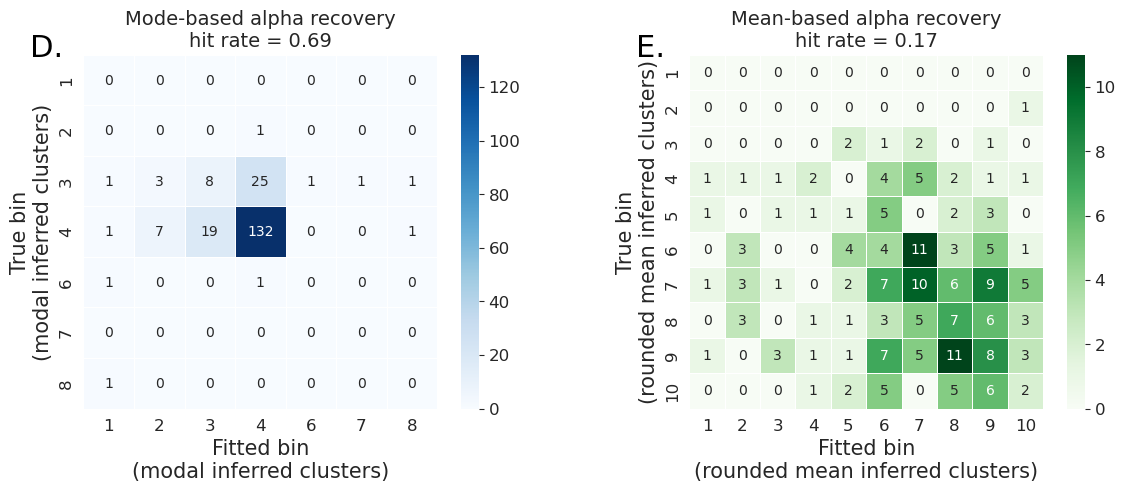


Saved figure to:
C:\Users\zyfxl\OneDrive - UC Irvine\UCI\CCNL Lab\Foraging Task Overview\foraging_MQLP-main\foraging_MQLP-main\data_analysis_new\alpha_discrete_recovery_modeK_meanK_DE.png


In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# DISCRETE ALPHA RECOVERY HEATMAPS
# D = modeK-bin recovery
# E = meanK-bin recovery
#
# Requires:
#   df["alpha_true"], df["alpha_est"]
#   alpha_map with columns ["alpha", "modeK", "meanK"]
# ============================================================

save_dir = r"C:\Users\zyfxl\OneDrive - UC Irvine\UCI\CCNL Lab\Foraging Task Overview\foraging_MQLP-main\foraging_MQLP-main\data_analysis_new"
os.makedirs(save_dir, exist_ok=True)

# ============================================================
# 1. Build nearest-grid alpha lookup
# ============================================================

grid_alpha = alpha_map["alpha"].to_numpy(dtype=float)
grid_modeK = alpha_map["modeK"].to_numpy(dtype=int)
grid_meanK = alpha_map["meanK"].to_numpy(dtype=float)

def nearest_grid_index(alpha_values):
    alpha_values = np.asarray(alpha_values, dtype=float)
    return np.abs(alpha_values[:, None] - grid_alpha[None, :]).argmin(axis=1)

idx_true = nearest_grid_index(df["alpha_true"].values)
idx_fit  = nearest_grid_index(df["alpha_est"].values)

# ============================================================
# 2. ModeK bins
# ============================================================

df["alpha_modeK_true"] = grid_modeK[idx_true]
df["alpha_modeK_fit"]  = grid_modeK[idx_fit]

mode_hit = (df["alpha_modeK_true"] == df["alpha_modeK_fit"]).mean()

mode_cm = pd.crosstab(
    df["alpha_modeK_true"],
    df["alpha_modeK_fit"]
)

# Ensure square matrix with all observed bins
mode_bins = sorted(set(df["alpha_modeK_true"]).union(set(df["alpha_modeK_fit"])))
mode_cm = mode_cm.reindex(index=mode_bins, columns=mode_bins, fill_value=0)

# ============================================================
# 3. MeanK bins
#    Here meanK is continuous, so discretize it into integer-rounded bins.
#    Example: meanK=4.87 -> bin 5
# ============================================================

df["alpha_meanK_true"] = grid_meanK[idx_true]
df["alpha_meanK_fit"]  = grid_meanK[idx_fit]

df["alpha_meanK_bin_true"] = np.rint(df["alpha_meanK_true"]).astype(int)
df["alpha_meanK_bin_fit"]  = np.rint(df["alpha_meanK_fit"]).astype(int)

mean_hit = (df["alpha_meanK_bin_true"] == df["alpha_meanK_bin_fit"]).mean()

mean_cm = pd.crosstab(
    df["alpha_meanK_bin_true"],
    df["alpha_meanK_bin_fit"]
)

mean_bins = sorted(set(df["alpha_meanK_bin_true"]).union(set(df["alpha_meanK_bin_fit"])))
mean_cm = mean_cm.reindex(index=mean_bins, columns=mean_bins, fill_value=0)

# ============================================================
# 4. Print recovery stats
# ============================================================

print("===================================================")
print("DISCRETE ALPHA RECOVERY")
print("===================================================")
print(f"N = {len(df)}")
print(f"ModeK hit rate = {mode_hit:.3f}")
print(f"MedianK-rounded hit rate = {mean_hit:.3f}")

print("\nModeK confusion matrix:")
print(mode_cm)

print("\nMeanK-rounded confusion matrix:")
print(mean_cm)

# ============================================================
# 5. Publication-style figure
# ============================================================

sns.set_style("white")

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 13,
    "axes.labelsize": 15,
    "axes.titlesize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "axes.linewidth": 1.4,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
})

def add_panel_label(ax, label):
    ax.text(
        -0.15, 1.06,
        label,
        transform=ax.transAxes,
        fontsize=22,
        fontweight="normal",
        ha="left",
        va="top",
        color="black"
    )

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
fig.patch.set_facecolor("white")

# ------------------------------------------------------------
# D. ModeK discrete recovery
# ------------------------------------------------------------

ax = axes[0]

sns.heatmap(
    mode_cm,
    ax=ax,
    cmap="Blues",
    annot=True,
    fmt="d",
    square=True,
    linewidths=0.5,
    linecolor="white",
    cbar=True,
    annot_kws={"fontsize": 10}
)

ax.set_xlabel("Fitted bin\n(modal inferred clusters)")
ax.set_ylabel("True bin\n(modal inferred clusters)")
ax.set_title(f"Mode-based alpha recovery\nhit rate = {mode_hit:.2f}")

add_panel_label(ax, "D.")

# ------------------------------------------------------------
# E. MeanK discrete recovery
# ------------------------------------------------------------

ax = axes[1]

sns.heatmap(
    mean_cm,
    ax=ax,
    cmap="Greens",
    annot=True,
    fmt="d",
    square=True,
    linewidths=0.5,
    linecolor="white",
    cbar=True,
    annot_kws={"fontsize": 10}
)

ax.set_xlabel("Fitted bin\n(rounded mean inferred clusters)")
ax.set_ylabel("True bin\n(rounded mean inferred clusters)")
ax.set_title(f"Mean-based alpha recovery\nhit rate = {mean_hit:.2f}")

add_panel_label(ax, "E.")

plt.tight_layout(w_pad=3)

fig_path = os.path.join(save_dir, "alpha_discrete_recovery_modeK_meanK_DE.png")
plt.savefig(fig_path, dpi=600, bbox_inches="tight", facecolor="white")
plt.show()

print(f"\nSaved figure to:\n{fig_path}")